In [1]:
%cd /work/project/escience/ruttho/FCCee_HiggLFV

/work/project/escience/ruttho/FCCee_HiggLFV


In [5]:
import pandas as pd
import os

def GetFinalAcceptance(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if "finalstate_nocut" in line:
                passEvt = int((line.split("(")[0].strip()).split(" ")[-1].strip())
                return passEvt
    return None

def GetTotalEvt(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if "Initial" in line:
                totalEvt = int((line.split("(")[0].strip()).split(" ")[-1].strip())
                return totalEvt
    return None

def GetThisCutTable(path, selection, data):
    path = os.path.join(path, "LOG")
    data_key = data.keys()
    files = [f for f in sorted(os.listdir(path)) if f.endswith(".txt")]
    # bg_files = [f for f in files if "ISR" in f]
    # # print(bg_files)
    # HLFV_files = [f for f in files if f.startswith("HLFV")]
    # VBF_files = [f for f in files if f.startswith("VBF")]
    
    for a in files:
        if "ISR" in a:
            name = ("_".join(a.split("_")[1:-1]))
        elif a.startswith("HLFV"):
            name = ("_".join(["HZ"] + a.split("_")[1:-1]))
        elif a.startswith("VBF"):
            name = ("_".join(["VBF"] + a.split("_")[2:-1]))
        else:
            continue
        phsp = a.split("_")[-1][:-7]
        filepath = os.path.join(path, a)
        evtpass = GetFinalAcceptance(filepath)
        selection_name = "_".join([phsp, selection])
        if name in data_key:
            data[name][selection_name] = evtpass
        else:
            data[name] = {selection_name: evtpass}

    return data

def GetTotalEventTable(path, selection, data):
    data_key = data.keys()
    path = os.path.join(path, "LOG")
    files = [f for f in sorted(os.listdir(path)) if f.endswith(".txt")]
    # bg_files = [f for f in files if "ISR" in f]
    # # print(bg_files)
    # HLFV_files = [f for f in files if f.startswith("HLFV")]
    # VBF_files = [f for f in files if f.startswith("VBF")]
    
    for a in files:
        if "ISR" in a:
            name = ("_".join(a.split("_")[1:-1]))
        elif a.startswith("HLFV"):
            name = ("_".join(["HZ"] + a.split("_")[1:-1]))
        elif a.startswith("VBF"):
            name = ("_".join(["VBF"] + a.split("_")[2:-1]))
        else:
            continue
        phsp = a.split("_")[-1][:-7]
        filepath = os.path.join(path, a)
        evtpass = GetTotalEvt(filepath)
        selection_name = "_".join([phsp, selection])
        if name in data_key:
            data[name][selection_name] = evtpass
        else:
            data[name] = {selection_name: evtpass}

    return data


# different number different from MassToPT
def diff_df(df_sorted_cols):
    df_diff = pd.DataFrame()
    for col in df_sorted_cols.columns:
        if "MasstoPT" in col:
            co_name = col.split("_")[0]
            for col2 in df_sorted_cols.columns:
                if co_name in col2 and "MasstoPT" not in col2:
                    df_diff[col2] = df_sorted_cols[col2] - df_sorted_cols[col]
    return df_diff

def diff_percent(df_sorted_cols):
    df_diff_percent = pd.DataFrame()
    for col in df_sorted_cols.columns:
        if "MasstoPT" in col:
            co_name = col.split("_")[0]
            for col2 in df_sorted_cols.columns:
                if co_name in col2 and "MasstoPT" not in col2:
                    df_diff_percent[col2] = (df_sorted_cols[col2] - df_sorted_cols[col]) / df_sorted_cols[col] * 100
    return df_diff_percent


basedir = os.path.join(os.getcwd(), "Results", "Selections")
process_types= os.listdir(basedir)
All_Final_Acceptance = {}
All_Total_Evt = {}
for process in process_types: # mue, etaumu
    All_Final_Acceptance[process] = {}
    All_Total_Evt[process] = {}
    selection_types = os.listdir(os.path.join(basedir, process))
    for selection in selection_types: # MasstoPT, etc
        All_Final_Acceptance[process] = GetThisCutTable(os.path.join(basedir, process, selection), selection, All_Final_Acceptance[process])
        All_Total_Evt[process] = GetTotalEventTable(os.path.join(basedir, process, selection), selection, All_Total_Evt[process])


df_dict={ "MuE": pd.DataFrame(All_Final_Acceptance["MuE"]).T , "ETauMu": pd.DataFrame(All_Final_Acceptance["ETauMu"]).T }
total_dict = { "MuE": pd.DataFrame(All_Total_Evt["MuE"]).T , "ETauMu": pd.DataFrame(All_Total_Evt["ETauMu"]).T }
df_sorted_cols = {key: df.sort_index(axis=1) for key, df in df_dict.items()}
total_sorted_cols = {key: df.sort_index(axis=1) for key, df in total_dict.items()}
pd.set_option('display.float_format', '{:.4f}'.format)
df_percent = {key: df_sorted_cols[key].div(total_sorted_cols[key].values) * 100 for key in df_sorted_cols.keys()}
# diff_percent_dict = {key: diff_percent(df) for key, df in df_sorted_cols.items()}
df_diff_dict = {key: diff_df(df) for key, df in df_sorted_cols.items()}
df_diff_percent_dict = {key: diff_df(df) for key, df in df_percent.items()}

In [18]:
df_dict["ETauMu"]

,21To81_PTtoMass,81To101_PTtoMass,21To81_MasstoPT,81To101_MasstoPT,21To81_OnlyPT,81To101_OnlyPT,21To81_NoPTMin,81To101_NoPTMin
HZ_110GeV,12088,210395,18334,367295,12088,210395,12139,212002
HZ_115GeV,12058,215071,18164,372788,12058,215071,12108,216457
HZ_120GeV,12300,218952,18744,376844,12300,218952,12342,220004
HZ_125GeV,12656,223270,19043,381697,12656,223270,12689,224085
HZ_130GeV,12755,228202,19744,385978,12755,228202,12792,228848
HZ_135GeV,13363,232895,20863,389025,13363,232895,13392,233414
HZ_140GeV,14735,235098,23168,388961,14735,235098,14773,235502
HZ_145GeV,19758,236669,31066,384756,19758,236669,19794,237034
HZ_150GeV,76376,193893,118453,292701,76376,193893,76437,194688
HZ_155GeV,186754,97809,280188,116669,186754,97809,186896,99668


<Axes: title={'center': 'Percentage Difference from MassToPT for MuE'}>

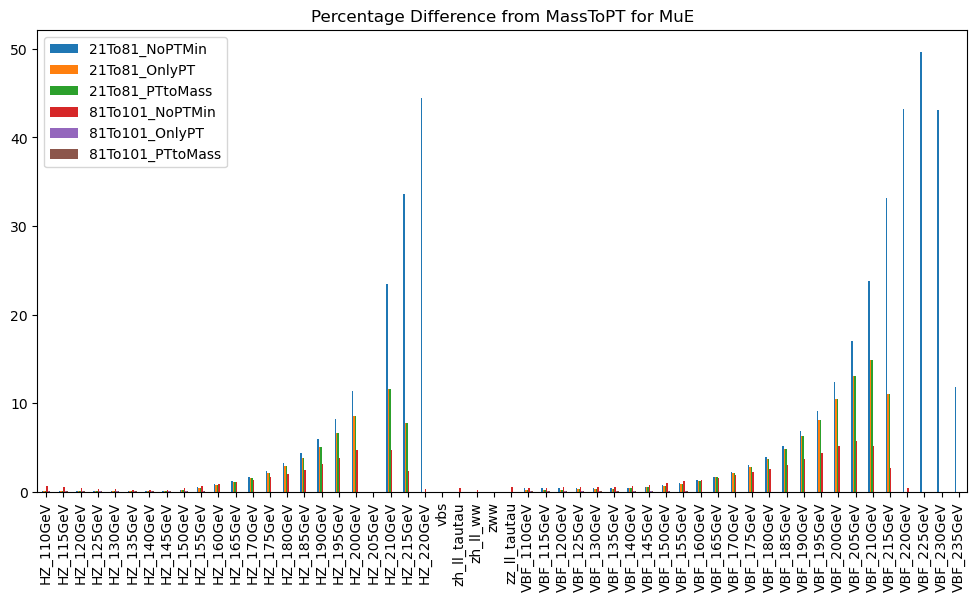

In [14]:
df_diff_percent_dict["MuE"].plot(kind='bar', figsize=(12, 6), title='Percentage Difference from MassToPT for MuE')

In [15]:
df_diff_percent_dict["MuE"]

,21To81_NoPTMin,21To81_OnlyPT,21To81_PTtoMass,81To101_NoPTMin,81To101_OnlyPT,81To101_PTtoMass
HZ_110GeV,0.0688,0.0537,0.0537,0.6372,0.0874,0.0874
HZ_115GeV,0.0616,0.0490,0.0490,0.5219,0.0686,0.0686
HZ_120GeV,0.0605,0.0478,0.0478,0.4609,0.0820,0.0820
HZ_125GeV,0.0651,0.0523,0.0523,0.3653,0.0679,0.0679
HZ_130GeV,0.0669,0.0543,0.0543,0.3045,0.0652,0.0652
HZ_135GeV,0.0659,0.0556,0.0556,0.2451,0.0617,0.0617
HZ_140GeV,0.0698,0.0576,0.0576,0.2263,0.0655,0.0655
HZ_145GeV,0.0748,0.0629,0.0629,0.2010,0.0619,0.0619
HZ_150GeV,0.2046,0.1808,0.1808,0.3794,0.1097,0.1097
HZ_155GeV,0.4928,0.4449,0.4449,0.6553,0.0666,0.0666


<Axes: title={'center': 'Difference from MassToPT for ETauMu'}>

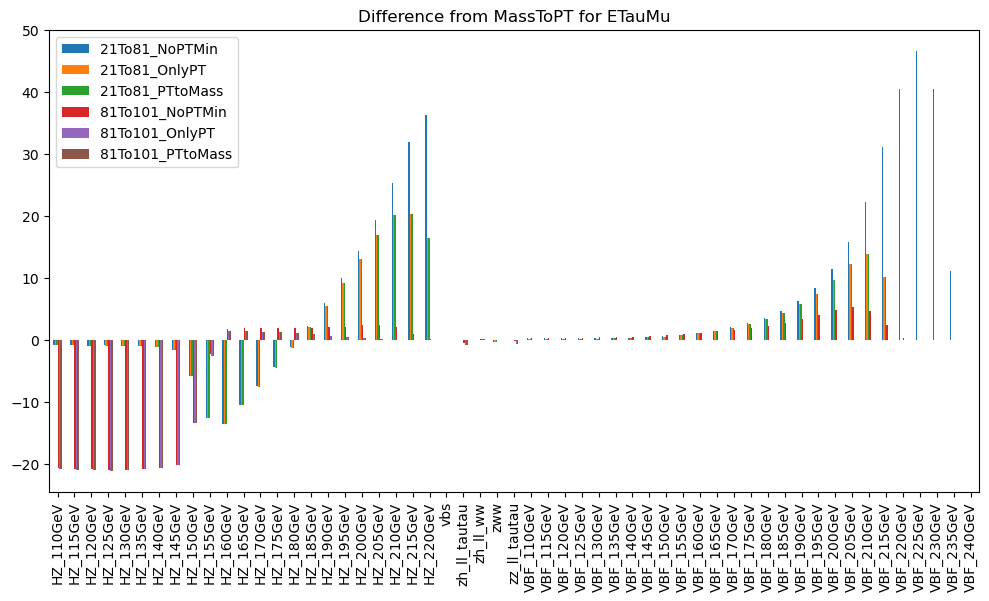

In [11]:
df_diff_percent_dict["ETauMu"].plot(kind='bar', figsize=(12, 6), title='Difference from MassToPT for ETauMu')

In [16]:
df_diff_percent_dict["ETauMu"]

,21To81_NoPTMin,21To81_OnlyPT,21To81_PTtoMass,81To101_NoPTMin,81To101_OnlyPT,81To101_PTtoMass
HZ_110GeV,-0.8195,-0.8262,-0.8262,-20.5427,-20.7552,-20.7552
HZ_115GeV,-0.8022,-0.8088,-0.8088,-20.7075,-20.8911,-20.8911
HZ_120GeV,-0.8492,-0.8548,-0.8548,-20.8038,-20.9434,-20.9434
HZ_125GeV,-0.8441,-0.8485,-0.8485,-20.9390,-21.0473,-21.0473
HZ_130GeV,-0.9249,-0.9298,-0.9298,-20.9043,-20.9902,-20.9902
HZ_135GeV,-0.9970,-1.0008,-1.0008,-20.7655,-20.8348,-20.8348
HZ_140GeV,-1.1276,-1.1327,-1.1327,-20.6117,-20.6660,-20.6660
HZ_145GeV,-1.5306,-1.5355,-1.5355,-20.0590,-20.1085,-20.1085
HZ_150GeV,-5.6996,-5.7078,-5.7078,-13.2956,-13.4035,-13.4035
HZ_155GeV,-12.5535,-12.5726,-12.5726,-2.2877,-2.5378,-2.5378
